# Notebook 04 — PyMatching MWPM Benchmark

**What this notebook does:**  
Runs the classical near-optimal decoder (Minimum Weight Perfect Matching via PyMatching)
across all noise levels. MWPM is the standard reference every NN decoder gets compared against.

**How it connects to Stim:**
```
circuit → detector_error_model() → PyMatching graph
                                         ↓
detection_events → decode_batch() → predicted_flips → LER
```

**Prerequisites:** Run notebooks 01, 02, 03 first.  
**Install:** `pip install pymatching`

In [1]:
import numpy as np
import stim
import pymatching
import matplotlib
import matplotlib.pyplot as plt
import os, time

print(f"Stim       : {stim.__version__}")
print(f"PyMatching : {pymatching.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")

Stim       : 1.15.0
PyMatching : 2.3.1
NumPy      : 2.2.6
Matplotlib : 3.10.8


---
## 1. Wilson Confidence Interval Helper

Stim's sinter library uses Wilson score CIs for all error bars.
This gives valid confidence intervals even when error counts are small.

In [2]:
def wilson_ci(num_errors, num_shots, z=1.96):
    """Wilson score CI — same method as Stim's sinter library.
    Returns (lo_err, hi_err) as asymmetric half-widths for plt.errorbar.
    """
    p      = num_errors / num_shots
    denom  = 1 + z**2 / num_shots
    centre = (p + z**2 / (2*num_shots)) / denom
    margin = z * np.sqrt(p*(1-p)/num_shots + z**2/(4*num_shots**2)) / denom
    lo = np.clip(centre - margin, 1e-10, 1.0)
    hi = np.clip(centre + margin, 1e-10, 1.0)
    return float(p - lo), float(hi - p)


def make_yerr(ler_list, shots):
    """Build 2×N yerr array for plt.errorbar from list of LERs."""
    pairs = [wilson_ci(max(1, round(ler*shots)), shots) for ler in ler_list]
    lo, hi = zip(*pairs)
    return np.array([lo, hi])


lo, hi = wilson_ci(54, 1000)
print(f"Sanity check: 54/1000 → lo={lo:.5f}  hi={hi:.5f}  (should be ~0.004, ~0.005)")

Sanity check: 54/1000 → lo=0.01238  hi=0.01579  (should be ~0.004, ~0.005)


---
## 2. MWPM Noise Sweep

In [3]:
DISTANCE     = 3
ROUNDS       = 9
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
SWEEP_SHOTS  = 50_000


def run_mwpm(p, num_shots):
    circ = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=ROUNDS, distance=DISTANCE,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )
    dem      = circ.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(dem)
    sampler  = circ.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    det      = np.array(det, dtype=np.bool_)
    obs      = np.array(obs, dtype=np.bool_)
    predicted = matching.decode_batch(det)
    return float(np.any(predicted != obs, axis=1).mean())


os.makedirs("results", exist_ok=True)
mwpm_lers = []

print(f"MWPM sweep ({SWEEP_SHOTS:,} shots per level)")
print(f"  {'p':>8}  {'LER':>10}  {'Time':>7}")
print("  " + "-"*30)

for p in NOISE_LEVELS:
    t0  = time.time()
    ler = run_mwpm(p, SWEEP_SHOTS)
    mwpm_lers.append(ler)
    print(f"  p={p:.4f}  LER={ler:.5f}  [{time.time()-t0:.1f}s]")

np.save("results/mwpm_sweep.npy",
        np.array(list(zip(NOISE_LEVELS, mwpm_lers))))
print("\nSaved → results/mwpm_sweep.npy")

MWPM sweep (50,000 shots per level)
         p         LER     Time
  ------------------------------
  p=0.0005  LER=0.00054  [0.1s]
  p=0.0010  LER=0.00228  [0.0s]
  p=0.0020  LER=0.00826  [0.1s]
  p=0.0050  LER=0.04520  [0.1s]
  p=0.0100  LER=0.15056  [0.2s]
  p=0.0200  LER=0.34456  [0.3s]

Saved → results/mwpm_sweep.npy


---
## 3. Stim-Style Plot

Exact style from the Stim/sinter getting-started notebook:
- `ax.loglog()` — both axes log scale  
- `ax.grid()` — minor and major grid  
- `ax.set_ylim(1e-5, 1)`  
- `ax.set_ylabel('Logical Error Probability (per shot)')`  
- `ax.set_xlabel('Physical Error Rate')`  
- Wilson CI error bars  
- p² reference slope

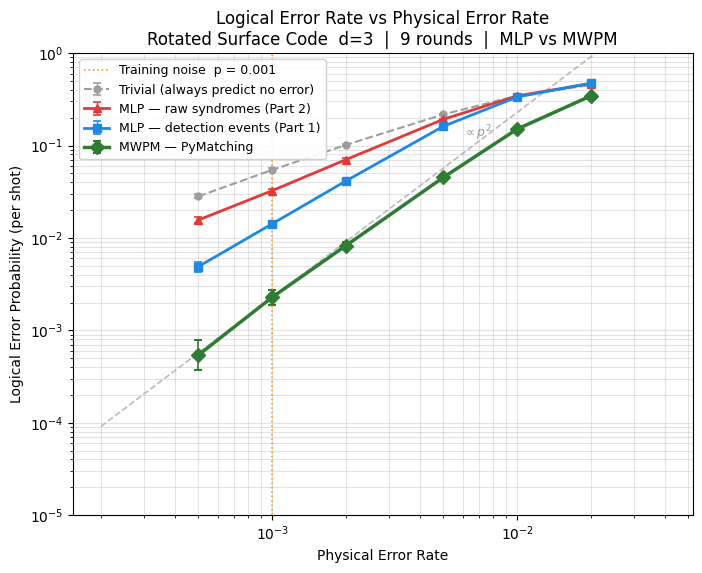

Saved → figures/04_mwpm_vs_mlp.png


In [4]:
# NN results from notebook 03 — update these if your sweep produced different numbers
NN = {
    'trivial': [0.02820, 0.05440, 0.10164, 0.21724, 0.34508, 0.45202],
    'mlp_p1':  [0.00490, 0.01420, 0.04134, 0.16152, 0.33486, 0.47316],
    'mlp_p2':  [0.01562, 0.03246, 0.07036, 0.19220, 0.34450, 0.46876],
}

ps = np.array(NOISE_LEVELS)
S  = SWEEP_SHOTS

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# p² reference slope anchored at MWPM p=0.001 point
p_ref = np.array([2e-4, 4e-2])
ax.plot(p_ref, mwpm_lers[1] * (p_ref / 0.001)**2,
        ls='--', color='#BBBBBB', lw=1.2, zorder=0)
ax.text(6e-3, mwpm_lers[1]*(6e-3/0.001)**2 * 1.5,
        r'$\propto p^2$', color='#999999', fontsize=9, style='italic')

# Trivial
ax.errorbar(ps, NN['trivial'], yerr=make_yerr(NN['trivial'], S),
            fmt='o--', color='#9E9E9E', lw=1.5, ms=5,
            capsize=3, capthick=1.2, elinewidth=1,
            label='Trivial (always predict no error)')

# MLP Part 2
ax.errorbar(ps, NN['mlp_p2'], yerr=make_yerr(NN['mlp_p2'], S),
            fmt='^-', color='#E53935', lw=2, ms=6,
            capsize=3, capthick=1.2, elinewidth=1,
            label='MLP — raw syndromes (Part 2)')

# MLP Part 1
ax.errorbar(ps, NN['mlp_p1'], yerr=make_yerr(NN['mlp_p1'], S),
            fmt='s-', color='#1E88E5', lw=2, ms=6,
            capsize=3, capthick=1.2, elinewidth=1,
            label='MLP — detection events (Part 1)')

# MWPM
ax.errorbar(ps, mwpm_lers, yerr=make_yerr(mwpm_lers, S),
            fmt='D-', color='#2E7D32', lw=2.5, ms=7,
            capsize=3, capthick=1.5, elinewidth=1.2,
            label='MWPM — PyMatching')

# Training noise
ax.axvline(x=0.001, color='#FF8F00', lw=1.2, ls=':', alpha=0.9,
           label='Training noise  p = 0.001')

# ── Exact Stim/sinter style ───────────────────────────────────────────────────
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid(which='both', alpha=0.35)
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.set_title('Logical Error Rate vs Physical Error Rate\n'
             'Rotated Surface Code  d=3  |  9 rounds  |  MLP vs MWPM')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

os.makedirs("figures", exist_ok=True)
fig.savefig('figures/04_mwpm_vs_mlp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/04_mwpm_vs_mlp.png")

---
## 4. Suppression Factor Table

In [5]:
print("=" * 58)
print("Suppression = trivial LER / decoder LER  (higher is better)")
print("=" * 58)
print(f"  {'p':>8}  {'MLP P1':>8}  {'MLP P2':>8}  {'MWPM':>8}")
print("  " + "-" * 38)
for i, p in enumerate(NOISE_LEVELS):
    t  = NN['trivial'][i]
    p1 = NN['mlp_p1'][i]
    p2 = NN['mlp_p2'][i]
    mw = mwpm_lers[i]
    fmt = lambda v: f"{t/v:.1f}x" if v > 0 else " inf"
    print(f"  p={p:.4f}  {fmt(p1):>8}  {fmt(p2):>8}  {fmt(mw):>8}")

Suppression = trivial LER / decoder LER  (higher is better)
         p    MLP P1    MLP P2      MWPM
  --------------------------------------
  p=0.0005      5.8x      1.8x     52.2x
  p=0.0010      3.8x      1.7x     23.9x
  p=0.0020      2.5x      1.4x     12.3x
  p=0.0050      1.3x      1.1x      4.8x
  p=0.0100      1.0x      1.0x      2.3x
  p=0.0200      1.0x      1.0x      1.3x
